In [5]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

import mps

In [168]:
N = 40
batch_size = 100

x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
x0[:, 0] = 1

x1 = x0.clone()
x1[:, 0] = 0

psi0 = torch.stack([x0, 1 - x0], dim=-1)
psi1 = torch.stack([x1, 1 - x1], dim=-1)

psi = torch.concat([psi0, psi1], dim=0)


In [169]:
from mps.tpcp_mps import MPSTPCP


tpcp = MPSTPCP(N, K=1, d=2, enable_r=True, with_identity=False, manifold=mps.tpcp_mps.ManifoldType.CANONICAL)

In [170]:
import geoopt
optimizer = geoopt.optim.RiemannianSGD(tpcp.params, lr=0.01)
tpcp.forward(psi)
loss = (tpcp.rho_list[-1][:batch_size] - tpcp.rho_list[-1][batch_size:]).norm()
loss.backward()
print(loss)

tensor(3.3069e-06, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)


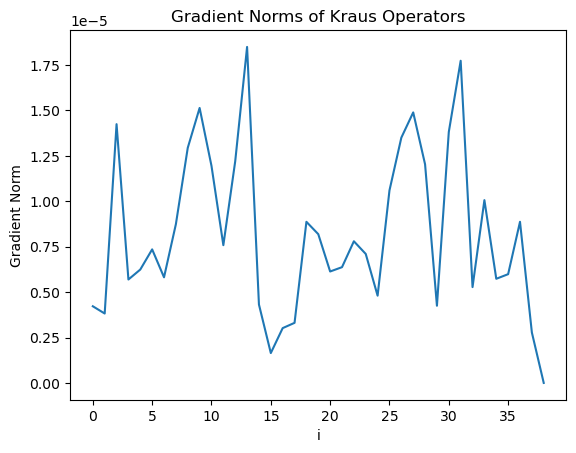

In [171]:
import matplotlib.pyplot as plt

norms = []
for i in range(len(tpcp.kraus_ops)):
    g = tpcp.kraus_ops[i].grad
    u = tpcp.kraus_ops[i]
    rg = u.T @ g - g.T @ u
    norms.append(torch.norm(rg).item())

plt.plot(norms)
plt.xlabel('i')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norms of Kraus Operators')
plt.show()

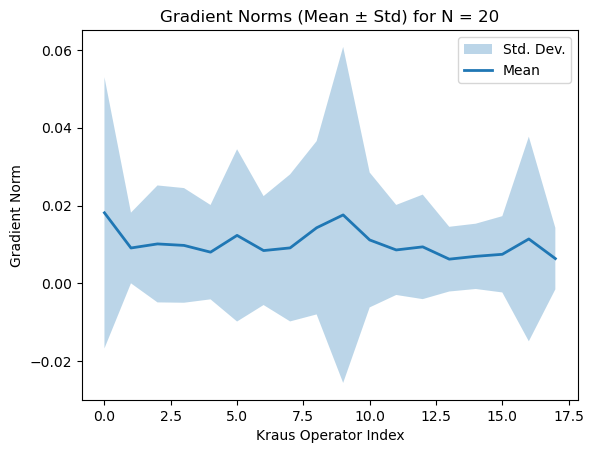

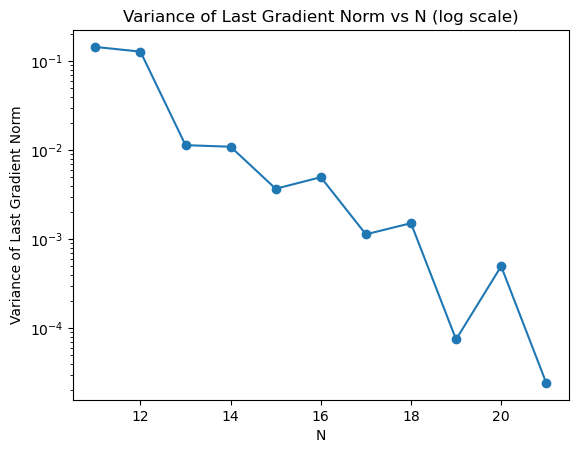

In [178]:
import mps.tpcp_mps
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3
import geoopt
import matplotlib.pyplot as plt
import math

# Set number of independent experiments per N
M = 20
# Use N values from 10 to 20 (inclusive)
N_list = list(range(11, 22))
batch_size = 100

# Dictionaries to store mean and variance (for the gradient norm at each Kraus index) for each N.
mean_dict = {}
var_dict = {}
# Also store the variance (over experiments) of the last Kraus operator's gradient norm.
last_grad_variances = []

# Loop over different system sizes N
for N in N_list:
    exp_grad_norms = []  # will be a list of arrays; each array is the gradient norms for all Kraus operators for one experiment
    
    for m in range(M):
        # --- Initialize the tpcp model ---
        # Here we assume that a new tpcp model can be constructed by mps.TPCP(N).
        # (Update this line if your model is constructed differently.)
        tpcp = mps.tpcp_mps.MPSTPCP(N, K=1, d=2, enable_r=True, with_identity=False, manifold=mps.tpcp_mps.ManifoldType.CANONICAL)
        
        # Create an optimizer (Riemannian SGD) over the model parameters.
        optimizer = geoopt.optim.RiemannianSGD(tpcp.params, lr=0.01)
        
        # --- Generate synthetic data ---
        # Create two sets of binary sequences with batch_size examples and length N.
        x0 = torch.randint(0, 2, (batch_size, N), dtype=torch.int64).to(torch.float64)
        x0[:, 0] = 1  # force the first bit to 1
        x1 = x0.clone()
        x1[:, 0] = 0  # force the first bit to 0
        
        # Create two wavefunctions psi0 and psi1 (each of shape (batch_size, N, 2))
        psi0 = torch.stack([x0, 1 - x0], dim=-1)
        psi1 = torch.stack([x1, 1 - x1], dim=-1)
        # Concatenate them (resulting shape: (2 * batch_size, N, 2))
        psi = torch.cat([psi0, psi1], dim=0)
        
        # --- Forward pass, loss, and backward pass ---
        tpcp.forward(psi)
        # The loss is defined as the norm difference between the outputs for psi0 and psi1.
        loss = (tpcp.rho_list[-1][:batch_size] - tpcp.rho_list[-1][batch_size:]).norm()
        optimizer.zero_grad()
        loss.backward()
        
        # --- Compute the gradient norm for each Kraus operator ---
        # For each Kraus operator u with gradient g, we compute:
        #    rg = u^T @ g - g^T @ u
        # and then take its norm.
        kraus_norms = []
        for i in range(len(tpcp.kraus_ops) - 1):
            op = tpcp.kraus_ops[i]
            g = op.grad
            u = op
            rg = u.T @ g - g.T @ u
            norm_val = torch.norm(rg).item()
            kraus_norms.append(norm_val)
        exp_grad_norms.append(kraus_norms)
    
    # Convert the list of experiments into a numpy array of shape (M, num_kraus)
    exp_grad_norms = np.array(exp_grad_norms)
    
    # Compute the mean and variance (across the M experiments) for each Kraus operator index.
    mean_vals = np.mean(exp_grad_norms, axis=0)
    var_vals = np.var(exp_grad_norms, axis=0)
    
    mean_dict[N] = mean_vals
    var_dict[N] = var_vals
    # Save the variance of the last Kraus operator's gradient norm.
    last_grad_variances.append(var_vals[8])

# --- Plot 1: Mean and standard deviation (filled area) for a given N ---
# For illustration, we choose N = 20.
N_plot = 20
mean_vals = mean_dict[N_plot]
# Here we use standard deviation (sqrt of variance) for the filled region.
std_vals = np.sqrt(var_dict[N_plot])
i_indices = np.arange(len(mean_vals))

plt.figure()
plt.fill_between(i_indices, mean_vals - std_vals, mean_vals + std_vals, alpha=0.3, label='Std. Dev.')
plt.plot(i_indices, mean_vals, linewidth=2, label='Mean')
plt.xlabel('Kraus Operator Index')
plt.ylabel('Gradient Norm')
plt.title(f'Gradient Norms (Mean ± Std) for N = {N_plot}')
plt.legend()
plt.show()

# --- Plot 2: Log plot of the variance of the last Kraus operator's gradient norm vs N ---
plt.figure()
plt.plot(N_list, last_grad_variances, marker='o')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Variance of Last Gradient Norm')
plt.title('Variance of Last Gradient Norm vs N (log scale)')
plt.show()
